In [6]:
import mitsuba as mi
import drjit as dr
import numpy as np
from sionna.rt import load_scene,PolarizedAntennaPattern, PlanarArray, AntennaPattern, register_antenna_pattern,register_polarization


In [ ]:
#Isotropic Pattern
tx_array = PlanarArray(
    num_rows=4,
    num_cols=1,
    vertical_spacing=0.00375,
    horizontal_spacing=0.0,
    pattern="iso",
    polarization="V")

d, g, eta = tx_array.antenna_pattern.compute_gain()
tx_array.show()
tx_array.antenna_pattern.show()

In [ ]:
#Dipole Pattern
tx_array = PlanarArray(
    num_rows=4,
    num_cols=1,
    vertical_spacing=0.00375,
    horizontal_spacing=0.0,
    pattern="dipole",
    polarization="V")

d, g, eta = tx_array.antenna_pattern.compute_gain()
tx_array.show()
tx_array.antenna_pattern.show()

In [ ]:
#tr38901 Pattern
tx_array = PlanarArray(
    num_rows=4,
    num_cols=1,
    vertical_spacing=0.00375,
    horizontal_spacing=0.0,
    pattern="tr38901",
    polarization="V")

d, g, eta = tx_array.antenna_pattern.compute_gain()
tx_array.show()
tx_array.antenna_pattern.show()

Directivity [dB]: 5.24
Gain [dB]: 1.55e-06
Efficiency [%]: 30.0


(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 2 Axes>)

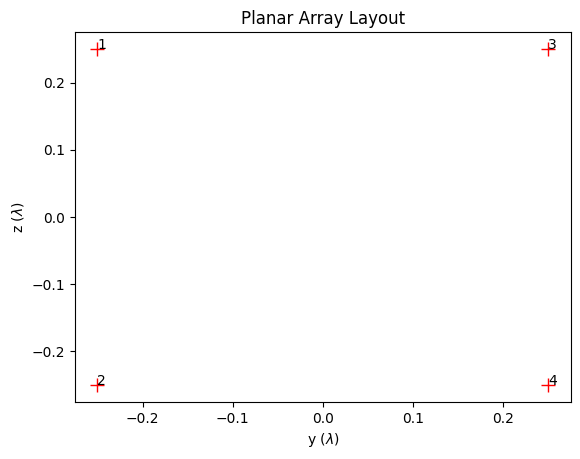

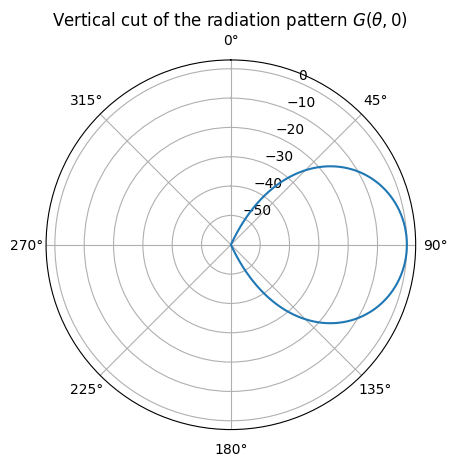

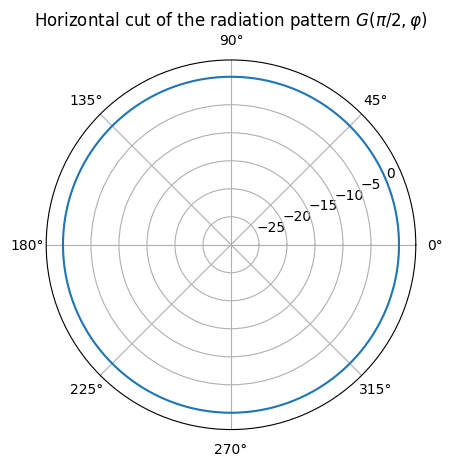

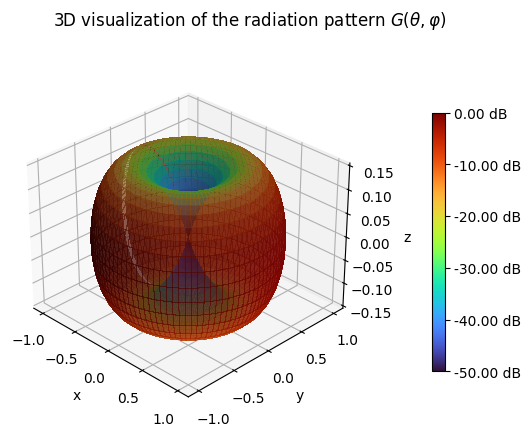

In [8]:
#Custom pattern example from documentation
def v_sin_pow_pattern(theta: mi.Float, phi: mi.Float, n: mi.Float) -> mi.Complex2f:
    return mi.Complex2f(dr.power(dr.sin(theta), n), 0)

def my_pattern_factory(*, n, polarization, polarization_model):
    """Factory method returning an instance of a PolarizedAntennaPattern
    with the newly created pattern function
    """
    return PolarizedAntennaPattern(
        v_pattern=lambda theta, phi: v_sin_pow_pattern(theta, phi, n),
        polarization=polarization,
        polarization_model=polarization_model
    )

register_antenna_pattern("my_pattern", my_pattern_factory)

# Register a custom polarization
# Since we provide two slant angles, the resulting
# antenna pattern will be dual-polarized
register_polarization("my_polarization", [-dr.pi/6, dr.pi*2/6])

# Use the custom antenna pattern with the rest of Sionna RT
array = PlanarArray(
        num_rows=2,
        num_cols=2,
        pattern="my_pattern",
        n=8,
        polarization="my_polarization",
        polarization_model="tr38901_1")
array.antenna_pattern.compute_gain()
array.show()
array.antenna_pattern.show()

In [ ]:
# Custom Pattern
def focused_element_pattern(theta: mi.Float, phi: mi.Float, sharpness: mi.Float) -> mi.Complex2f:
    # Diferencia respecto al centro direccional
    theta_diff = theta - (dr.pi / 2.0)
    phi_diff = phi

    # Decaimiento exponencial: entre mayor sea 'sharpness', más angosto es el haz
    exponent = -sharpness * (dr.square(theta_diff) + dr.square(phi_diff))
    mag = dr.exp(exponent)

    # Retornamos el campo eléctrico complejo (amplitud 'mag', fase 0)
    return mi.Complex2f(mag, 0)

# 2. La Clase Envoltorio de Sionna
class FocusedPattern(AntennaPattern):
    def __init__(self, sharpness):
        super().__init__()
        self.sharpness = sharpness
        # Sionna exige registrar la polarización (Vertical en este caso)
        self.patterns = [self.eval_pattern]

    def eval_pattern(self, theta, phi):
        c_theta = focused_element_pattern(theta, phi, self.sharpness)
        # Rellenamos la componente horizontal con ceros, tal como dicta la documentación
        c_phi = dr.zeros(mi.Complex2f, dr.width(c_theta))
        return c_theta, c_phi

# 3. La Fábrica (Factory Method) y el Registro
def focused_pattern_factory(sharpness=10.0):
    return FocusedPattern(sharpness=sharpness)

# Inyectamos tu patrón en la base de datos de Sionna
register_antenna_pattern("mi_patron_enfocado", focused_pattern_factory)

# ==========================================================
# 4. Uso en tu Escena: Antena ULA con Patrón Custom
# ==========================================================

# Ahora puedes llamar a tu patrón por nombre y pasarle el parámetro 'sharpness'
mimo_array_tx = PlanarArray(
    num_rows=4,                   # Mantenemos 1 fila (ULA)
    num_cols=1,                  # Tus 16 elementos para máxima directividad
    vertical_spacing=0.00375,
    horizontal_spacing=0.00375,
    pattern="mi_patron_enfocado", # ¡Invocamos tu creación!
    sharpness=60.0               # A mayor número, el elemento base es más "láser"
)

# Visualizamos tu obra maestra
mimo_array_tx.show()
mimo_array_tx.antenna_pattern.compute_gain();
mimo_array_tx.antenna_pattern.show()

In [ ]:

class PatronULAMatlab(AntennaPattern):
    def __init__(self):
        super().__init__()
        self.patterns = [self.eval_pattern]

    def eval_pattern(self, theta, phi):
        # 1. PARÁMETROS FÍSICOS (Idéntico a tu MATLAB)
        f = 40e9
        c = 3e8
        l = c / f
        d = l / 2
        no_elements = 4

        # 2. LOS PESOS (w) - Fases iniciales convertidas a radianes
        # Tu MATLAB: init_phases_deg = [0, -90, -180, -270]
        phases_rad = [0.0, -dr.pi/2, -dr.pi, -3*dr.pi/2]

        # Amplitudes (amp)
        amps = [1.0, 1.0, 1.0, 1.0]

        # Inicializamos la sumatoria de "r" (0 + 0j)
        r_sum = mi.Complex2f(0.0, 0.0)

        # 3. EL BUCLE (Equivalente a tus matrices en MATLAB)
        # Python cuenta desde 0 (0, 1, 2, 3), así que "n" ya equivale a tu "(n-1)"
        for n in range(no_elements):

            # --- Equivalente a: w = amp .* exp(1i * deg2rad(init_phases_deg)) ---
            # Euler: e^(jx) = cos(x) + j*sin(x)
            w = mi.Complex2f(
                amps[n] * dr.cos(phases_rad[n]),
                amps[n] * dr.sin(phases_rad[n])
            )

            # --- Equivalente a: A = (n-1) * (i * 2 * pi * d * cos(theta)) / l ---
            # NOTA: En 3D, usamos phi (acimut) en lugar de theta, y lo proyectamos con sin(theta)
            A_imaginario = (n) * (2 * dr.pi * d * dr.cos(phi) * dr.sin(theta)) / l

            # --- Equivalente a: X = exp(-A) ---
            X = mi.Complex2f(
                dr.cos(-A_imaginario),
                dr.sin(-A_imaginario)
            )

            # --- Equivalente a: r = w * X (y sumamos al total) ---
            r_sum += w * X

        # Normalizamos dividiendo entre el número de elementos
        r_sum /= no_elements

        # Sionna requiere devolver el campo en theta y phi (polarización)
        # Asignamos nuestra matemática al campo principal (Vertical)
        c_theta = r_sum
        c_phi = dr.zeros(mi.Complex2f, dr.width(c_theta))

        return c_theta, c_phi

# Registramos tu patrón personalizado
register_antenna_pattern("ula_matlab_custom", lambda **kwargs: PatronULAMatlab())

# ⚠️ ¡CRÍTICO! Como tu patrón YA ES un arreglo de 4 antenas matemáticamente,
# en Sionna solo declaras 1 antena. Si pones 4, Sionna hará un arreglo de arreglos.
tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,  # Solo 1, el patrón hace el resto
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
    pattern="ula_matlab_custom",
    polarization="V"
)

tx_array.antenna_pattern.compute_gain()
tx_array.show()
tx_array.antenna_pattern.show()